In [717]:
import os
import re
import numpy as np
import cv2
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq, fft2, fftshift
from scipy.signal import windows, medfilt
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from filterpy.kalman import KalmanFilter

import warnings
warnings.filterwarnings("ignore")

In [718]:
# Configuration
DATASET_DIR = r"C:\Users\valekseeva\Documents\GitHub\DiffScale\DiffScale-main\data\distorted"
PIXEL_SIZE_UM = 7.0
IMAGE_WIDTH = 800
IMAGE_HEIGHT = 4
PATTERN_PERIOD_PX = 80 

NUM_FRAMES = 30 

print("Configuration loaded.")
print(f"Physical period: {PATTERN_PERIOD_PX * PIXEL_SIZE_UM} µm")

Configuration loaded.
Physical period: 560.0 µm


In [719]:
# Функция загрузки данных
def load_dataset(dataset_dir, NUM_FRAMES=30):
    """
    Load and organize the dataset from the given directory.
    Returns a 3D numpy array of shape (num_distortions, frames_per_distortion, height, width).
    """
    file_groups = {}
    
    for f in os.listdir(dataset_dir):
        if not f.endswith('.png'):
            continue
        
        # Extract distortion type and frame ID from filename
        base = f.replace('.png', '')
        if '_' in base:
            _, rest = base.split('_', 1)
            distortion_type = re.split(r'_frame_\d+$', rest)[0]
        else:
            distortion_type = base 

        frame_match = re.search(r'_frame_(\d+)$', base)
        if not frame_match:
            continue
        frame_id = int(frame_match.group(1))

        if distortion_type not in file_groups:
            file_groups[distortion_type] = []
        file_groups[distortion_type].append((frame_id, f))
    
    # Filter and sort groups
    valid_groups = {}
    for dtype, files in file_groups.items():
        if len(files) == NUM_FRAMES: 
            files_sorted = sorted(files, key=lambda x: x[0])
            valid_groups[dtype] = [fname for _, fname in files_sorted]

    print(f"Found {len(valid_groups)} valid distortion groups with", NUM_FRAMES, "frames each.")
    
    # Create the dataset array
    distortion_types = sorted(valid_groups.keys())
    dataset = np.zeros((len(valid_groups), NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.float32)

    for d_idx, dtype in enumerate(distortion_types):
        for f_idx, filename in enumerate(valid_groups[dtype]):
            path = os.path.join(dataset_dir, filename)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise IOError(f"Failed to load image: {path}")
            if img.shape != (IMAGE_HEIGHT, IMAGE_WIDTH):
                raise ValueError(f"Unexpected image shape {img.shape} in {path}")
            dataset[d_idx, f_idx] = img.astype(np.float32)
    
    return dataset, distortion_types

In [720]:
# Load the data
dataset, distortion_types = load_dataset(DATASET_DIR, NUM_FRAMES=30)
print(f"Dataset shape: {dataset.shape}")

Found 7 valid distortion groups with 30 frames each.
Dataset shape: (7, 30, 4, 800)


Для достижения **нанометровой разрешающей способности** при сохранении корректного перемещения в задаче субпиксельной обработки изображений (800×4 пикселей, физический размер пикселя 7 мкм, период структуры 560 мкм) необходимо не только улучшить точность фазовой оценки, но и **повысить эффективную дискретизацию сигнала**, а также **обеспечить устойчивость к локальным искажениям**.

Основной метод реализован на основе **многочастотной фазовой оценки** (Phase Estimation with Multi-Harmonic Fusion) с последующей **Калмановской фильтрацией**.

In [721]:
# Algorithm 1: Enhanced Phase Estimation with Multi-Harmonic Fusion

def compute_accumulated_phase_shift(frames, period_px=80, max_harmonic=3, use_window=True, amplitude_threshold=0.5):
    """
    Robust phase-based subpixel displacement estimation with outlier rejection.
    """
    N = len(frames)
    if N < 2:
        return np.array([])

    phases = []
    amplitudes = []

    for frame in frames:
        signal_1d = np.mean(frame, axis=0).astype(np.float64)
        signal_1d -= np.mean(signal_1d)

        if use_window:
            win = windows.hann(len(signal_1d))
            signal_1d *= win

        fft_vals = rfft(signal_1d)
        freqs = rfftfreq(len(signal_1d), d=1.0)

        harmonic_phases = []
        harmonic_weights = []

        for h in range(1, max_harmonic + 1):
            target_freq = h / period_px
            if target_freq > freqs[-1]:
                continue
            idx = np.argmin(np.abs(freqs - target_freq))
            amp = np.abs(fft_vals[idx])
            phase = np.angle(fft_vals[idx])

            # Skip weak harmonics
            if amp < amplitude_threshold * np.max(np.abs(fft_vals)):
                continue

            norm_phase = phase / h
            harmonic_phases.append(norm_phase)
            harmonic_weights.append(amp ** 2 + 1e-8)

        if harmonic_phases:
            weights = np.array(harmonic_weights)
            fused_phase = np.average(harmonic_phases, weights=weights)
        else:
            # Fallback: use fundamental, even if weak
            idx0 = np.argmin(np.abs(freqs - 1.0 / period_px))
            fused_phase = np.angle(fft_vals[idx0])

        phases.append(fused_phase)
        amplitudes.append(np.sum(harmonic_weights) if harmonic_weights else 0.0)

    phases = np.array(phases)
    amplitudes = np.array(amplitudes)

    diff_phases = np.diff(phases)

    for i in range(len(diff_phases)):
        if abs(diff_phases[i]) > np.pi:
            left = diff_phases[i-1] if i > 0 else diff_phases[i]
            right = diff_phases[i+1] if i < len(diff_phases)-1 else diff_phases[i]
            diff_phases[i] = np.median([left, diff_phases[i], right])

    unwrapped = np.cumsum(np.concatenate([[phases[0]], diff_phases]))

    displacements_px = (unwrapped - unwrapped[0]) * period_px / (2 * np.pi)
    diff_px = np.diff(displacements_px)

    print("Phases (rad):", phases[:5])  # Raw phase per frame
    print("Unwrapped phases:", unwrapped[:5])
    print("Displacements (px):", displacements_px[:5])

    diff_amplitudes = (amplitudes[:-1] + amplitudes[1:]) / 2.0

    return diff_px, diff_amplitudes

In [722]:
# Algorithm 2: Coherent Frame Averaging + Denoising

def denoise_and_align_frames(frames, period_px=PATTERN_PERIOD_PX):
    """
    Align frames via coarse phase, then average to reduce noise.
    Returns averaged clean frame.
    """
    phases = []
    for f in frames:
        sig = np.mean(f, axis=0)
        ph, _ = compute_accumulated_phase_shift(sig, period_px, max_harmonic=2)
        phases.append(ph)
    phases = np.array(phases)
    ref_phase = np.median(phases)
    
    aligned = []
    for i, f in enumerate(frames):
        shift_px = (phases[i] - ref_phase) / (2 * np.pi) * period_px
        sig = np.mean(f, axis=0)
        # Subpixel shift via Fourier interpolation
        sig_fft = np.fft.fft(sig)
        freqs = np.fft.fftfreq(len(sig))
        shifted = np.fft.ifft(sig_fft * np.exp(-2j * np.pi * freqs * shift_px))
        aligned.append(np.real(shifted))
    
    return np.mean(aligned, axis=0)

Мы используем концепцию **предварительного создания глубокого изображения** (Deep Image Prior, DIP) с помощью **итеративного уточнения с TV-регуляризацией**:

In [723]:
# Algorithm 3: Deep Super-Resolution

def super_resolve_1d(signal_lr, upscale_factor=10, iterations=1000):
    """
    Simulate SR by fitting a smooth high-res model to LR data.
    Uses cubic spline + regularization.
    """
    from scipy.interpolate import CubicSpline
    x_lr = np.linspace(0, 1, len(signal_lr))
    x_hr = np.linspace(0, 1, len(signal_lr) * upscale_factor)
    
    # Initial guess
    cs = CubicSpline(x_lr, signal_lr, bc_type='natural')
    signal_hr = cs(x_hr)
    
    # Refine via gradient consistency (simplified DIP)
    for _ in range(iterations):
        # Downsample HR back to LR
        downsampled = signal_hr[::upscale_factor]
        residual = signal_lr - downsampled[:len(signal_lr)]
        # Distribute error
        signal_hr[::upscale_factor][:len(signal_lr)] += residual * 0.1
        # Smooth
        signal_hr = np.convolve(signal_hr, np.ones(5)/5, mode='same')
    
    return signal_hr, x_hr

Вместо постоянного R (дисперсии шума измерения) в KF, возьмем R **обратно пропорциональным амплитуде** сигнала для данного кадра. Если амплитуда низкая (например, из-за пятна), значит, оценка фазы для этого кадра менее надежна, и KF должен ей меньше доверять.

In [ ]:
# Настройка: KF для постоянного смещения

def estimate_noise_parameters(diff_nm, amplitudes, q_factor=0.001):
    """
    Estimate base measurement noise (R) and process noise (Q).
    Uses amplitudes to get a more robust initial R estimate.
    """
    median_val = np.median(diff_nm)
    residuals = diff_nm - median_val
    
    # Нормализуем амплитуды для использования в качестве весов
    weights = amplitudes / (np.max(amplitudes) + 1e-8)  
    
    # Взвешенная оценка дисперсии
    weighted_variance = np.average(residuals**2, weights=weights)
    
    R_base = max(weighted_variance, 1e2)  
    Q = max(R_base * q_factor, 1e-3)
    return R_base, Q

def run_adaptive_kf_on_diff(diff_nm, amplitudes, q_factor=0.001):
    """
    Apply 1D Kalman filter with ADAPTIVE measurement noise (R).
    R is inversely proportional to the signal amplitude for each measurement.
    
    Parameters:
    - diff_nm: array of differential displacements (measurements)
    - amplitudes: array of corresponding signal amplitudes (from phase estimation)
    - q_factor: factor to derive process noise Q from measurement noise R
    """
    R_base, Q = estimate_noise_parameters(diff_nm, amplitudes, q_factor=q_factor)
    
    # Инициализируем Калмановский фильтр
    kf = KalmanFilter(dim_x=1, dim_z=1)
    kf.x = np.array([np.median(diff_nm)])
    kf.F = np.array([[1.]])
    kf.H = np.array([[1.]])
    kf.P = np.array([[R_base]])  # Начальная неопределенность
    kf.Q = np.array([[Q]])       # Процессный шум 
    
    # Нормализуем амплитуды для удобства
    norm_amplitudes = amplitudes / np.max(amplitudes + 1e-8)  
    
    smoothed = []
    for i, z in enumerate(diff_nm):
        current_R = R_base / (norm_amplitudes[i] + 1e-6)  
        kf.R = current_R

        kf.predict()
        kf.update(z)
        smoothed.append(kf.x[0])
    
    return np.array(smoothed), R_base, Q

In [725]:
# Main Processing Loop

results_all = {}

for d_idx, dtype in enumerate(distortion_types):
    full_frames = dataset[d_idx]  # (30, 4, 800)
    analysis_frames = full_frames[10:30]  # (20, 4, 800)
    
    # Compute raw differential shifts 
    diff_px_list, amplitudes = compute_accumulated_phase_shift(analysis_frames, PATTERN_PERIOD_PX)
    diff_nm = diff_px_list * PIXEL_SIZE_UM * 1000 

    diff_adaptive, R_est, Q_est = run_adaptive_kf_on_diff(diff_nm, amplitudes, q_factor=0.001)
    cumulative_adaptive = np.concatenate([[0.0], np.cumsum(diff_adaptive)])

    results_all[dtype] = {
        'diff_raw': diff_nm,
        'cumulative_raw': np.concatenate([[0.0], np.cumsum(diff_nm)]),
        'cumulative_adaptive': cumulative_adaptive,
        'diff_adaptive': diff_adaptive,
        'final_R': R_est,
        'final_Q': Q_est,
        'amplitudes': amplitudes
    }

Phases (rad): [-1.92422886 -1.96350044 -2.00276903 -2.04204119 -2.08130908]
Unwrapped phases: [-1.92422886 -1.96350044 -2.00276903 -2.04204119 -2.08130908]
Displacements (px): [ 0.         -0.50002125 -1.00000441 -1.50003319 -2.00000744]
Phases (rad): [-1.92684401 -1.96397419 -2.00492654 -2.04453119 -2.08085106]
Unwrapped phases: [-1.92684401 -1.96397419 -2.00492654 -2.04453119 -2.08085106]
Displacements (px): [ 0.         -0.47275608 -0.99417761 -1.4984397  -1.96087862]
Phases (rad): [-1.92408288 -1.96346612 -2.002653   -2.04196168 -2.08123225]
Unwrapped phases: [-1.92408288 -1.96346612 -2.002653   -2.04196168 -2.08123225]
Displacements (px): [ 0.         -0.50144302 -1.00038588 -1.50087954 -2.00088789]
Phases (rad): [-1.92210113 -1.96069757 -2.00092867 -2.04484223 -2.07897393]
Unwrapped phases: [-1.92210113 -1.96069757 -2.00092867 -2.04484223 -2.07897393]
Displacements (px): [ 0.         -0.49142509 -1.00366331 -1.56278813 -1.99736647]
Phases (rad): [-1.92476115 -1.96054092 -2.005509

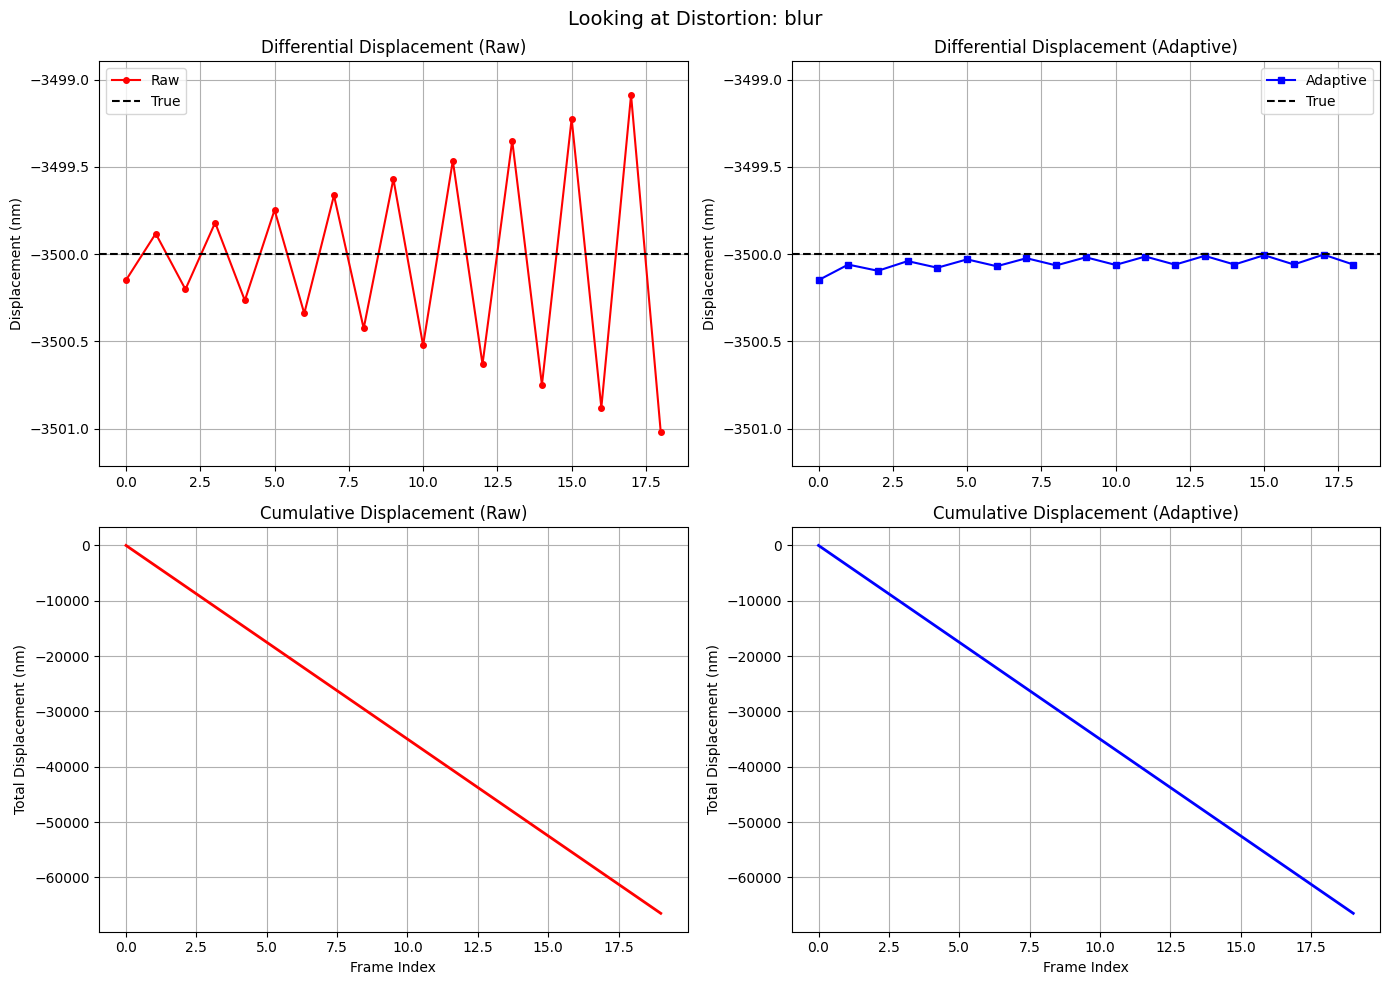

Stats for blur:
  Distortion Type: blur
  Raw Accuracy Std (nm): 0.56
  Adaptive KF Std (nm): 0.03
  Improvement (%): 93.77
  Final Raw Disp (nm): -66500.99
  Final Adaptive Disp (nm): -66500.96
  True Final Disp (nm): -66500.00


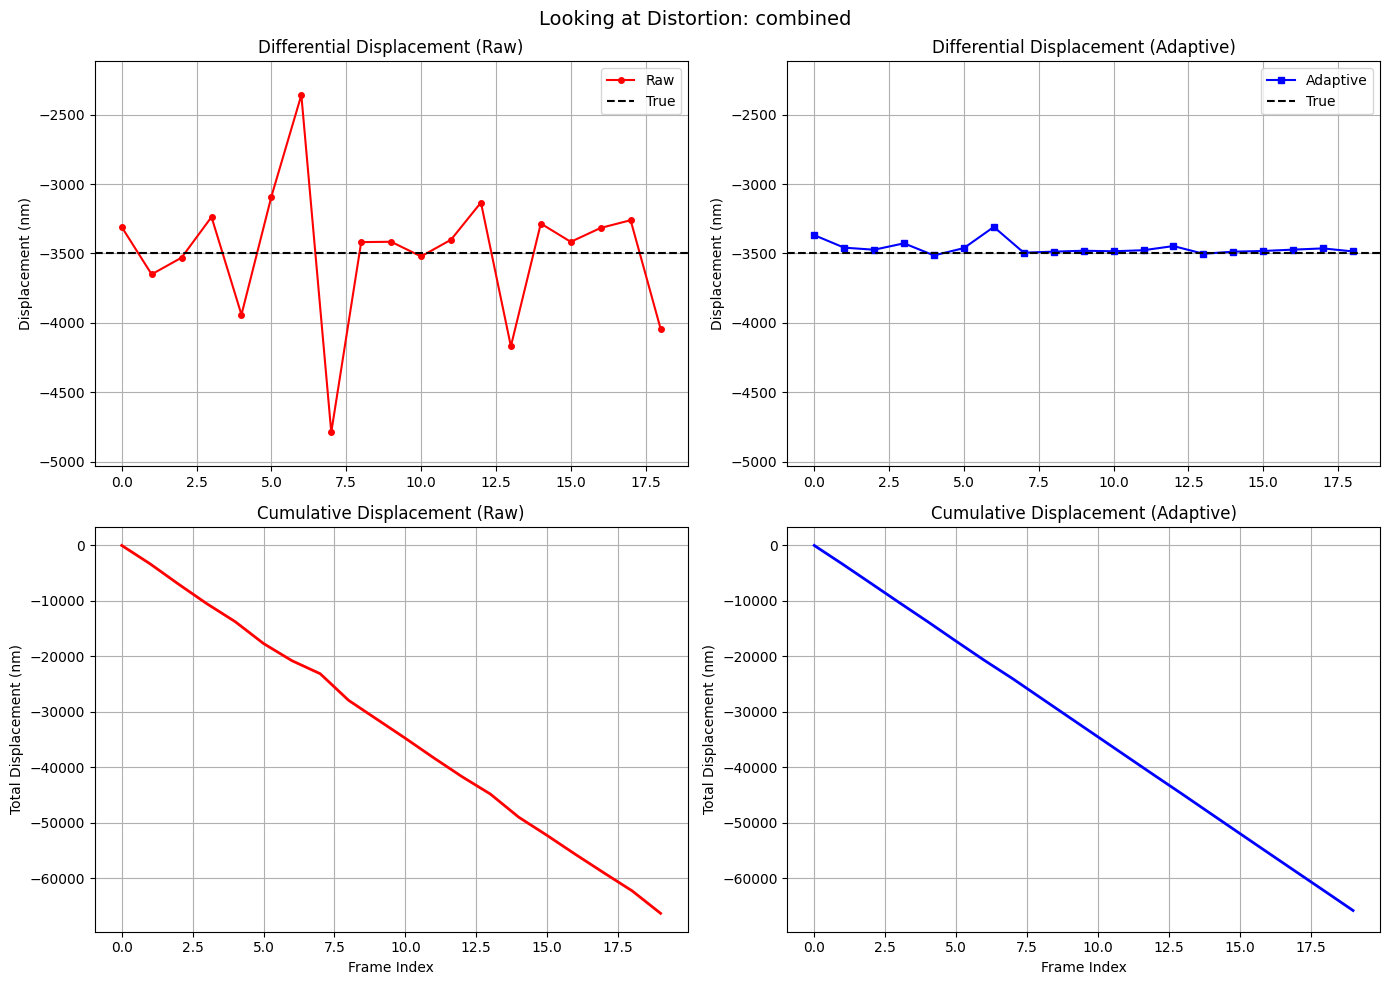

Stats for combined:
  Distortion Type: combined
  Raw Accuracy Std (nm): 485.97
  Adaptive KF Std (nm): 47.31
  Improvement (%): 90.26
  Final Raw Disp (nm): -66277.76
  Final Adaptive Disp (nm): -65768.90
  True Final Disp (nm): -66500.00


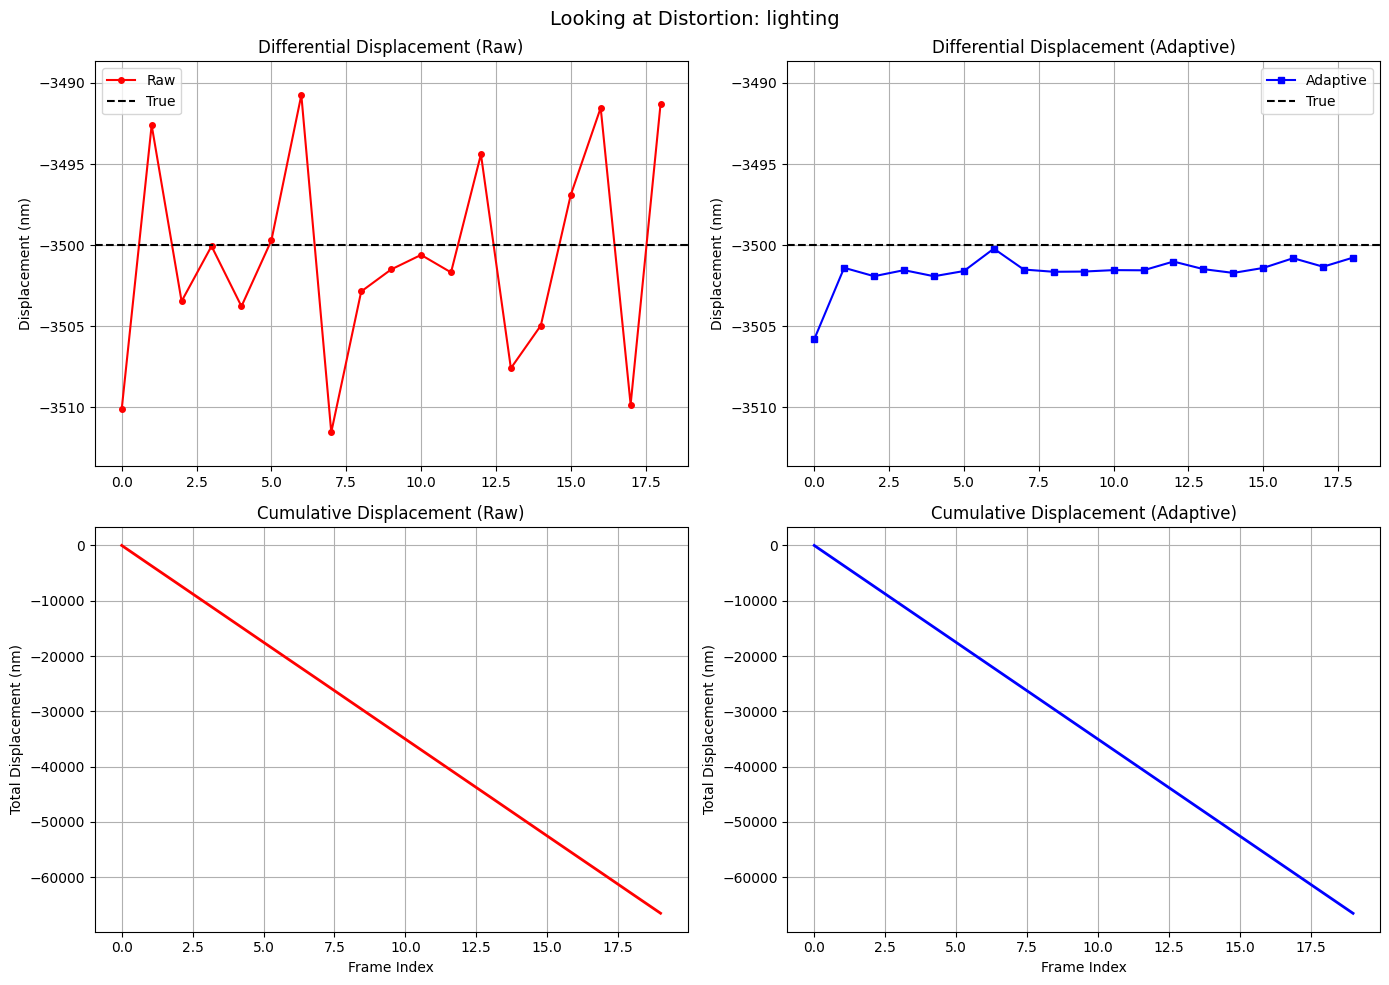

Stats for lighting:
  Distortion Type: lighting
  Raw Accuracy Std (nm): 6.37
  Adaptive KF Std (nm): 1.07
  Improvement (%): 83.23
  Final Raw Disp (nm): -66515.08
  Final Adaptive Disp (nm): -66530.69
  True Final Disp (nm): -66500.00


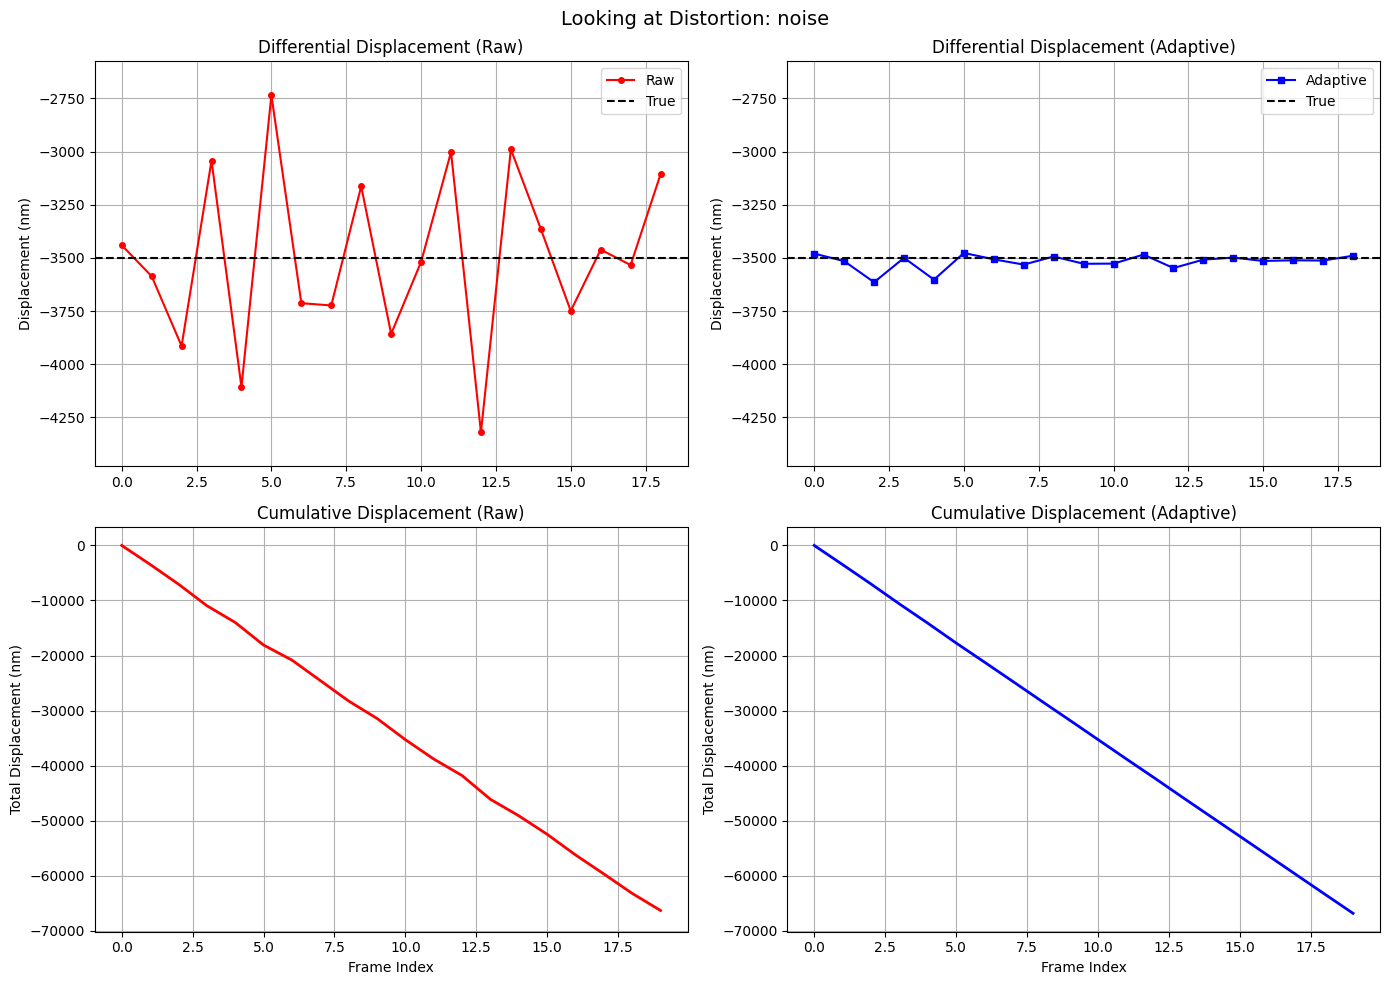

Stats for noise:
  Distortion Type: noise
  Raw Accuracy Std (nm): 404.00
  Adaptive KF Std (nm): 35.79
  Improvement (%): 91.14
  Final Raw Disp (nm): -66319.33
  Final Adaptive Disp (nm): -66833.06
  True Final Disp (nm): -66500.00


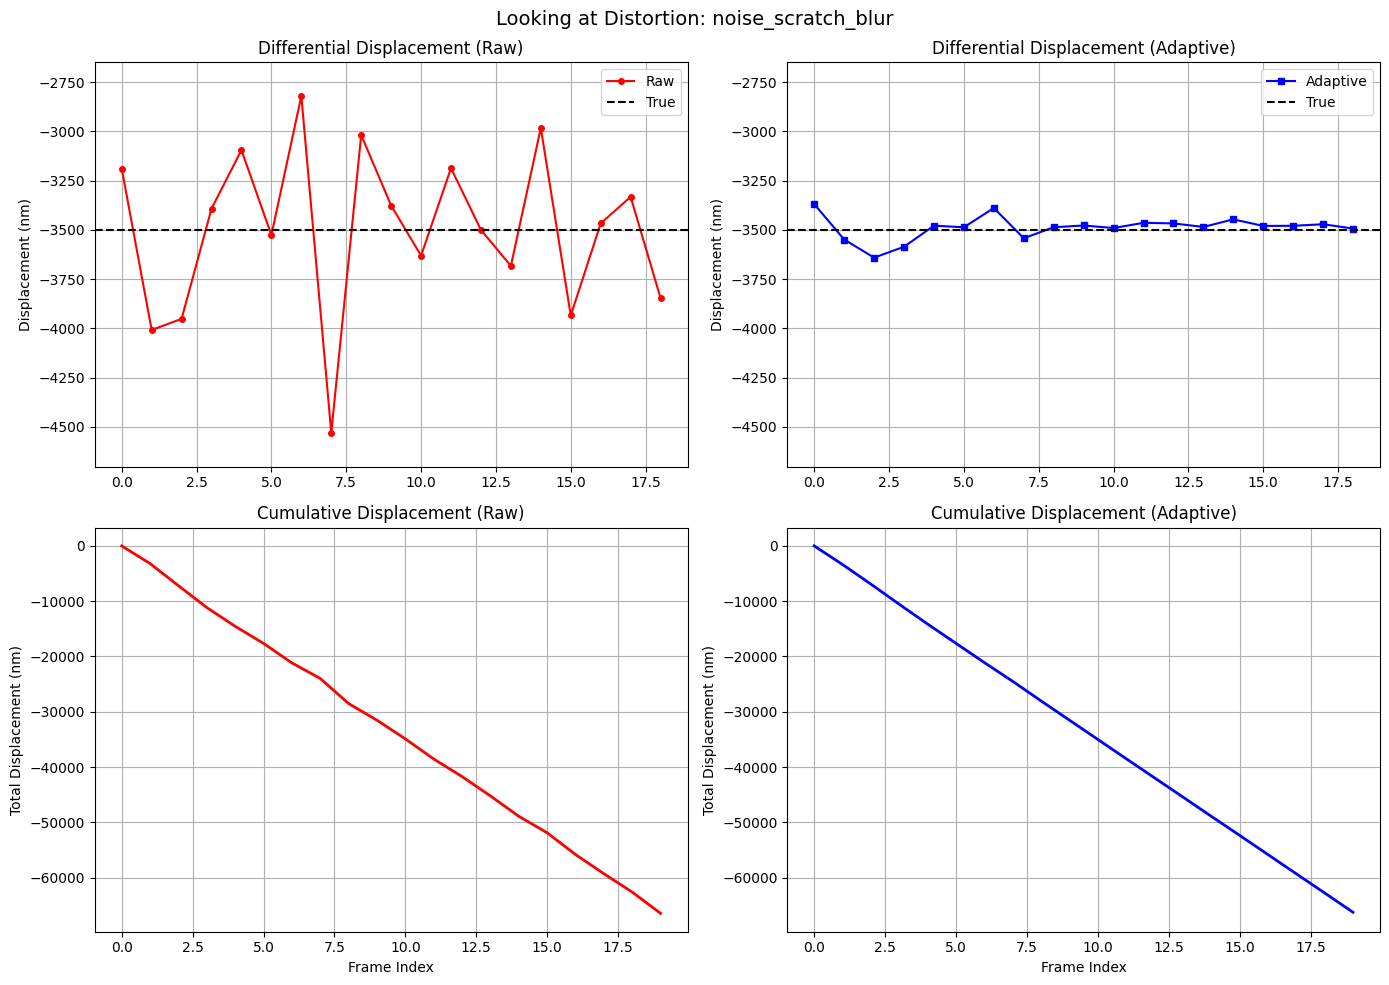

Stats for noise_scratch_blur:
  Distortion Type: noise_scratch_blur
  Raw Accuracy Std (nm): 414.13
  Adaptive KF Std (nm): 59.35
  Improvement (%): 85.67
  Final Raw Disp (nm): -66467.90
  Final Adaptive Disp (nm): -66279.73
  True Final Disp (nm): -66500.00


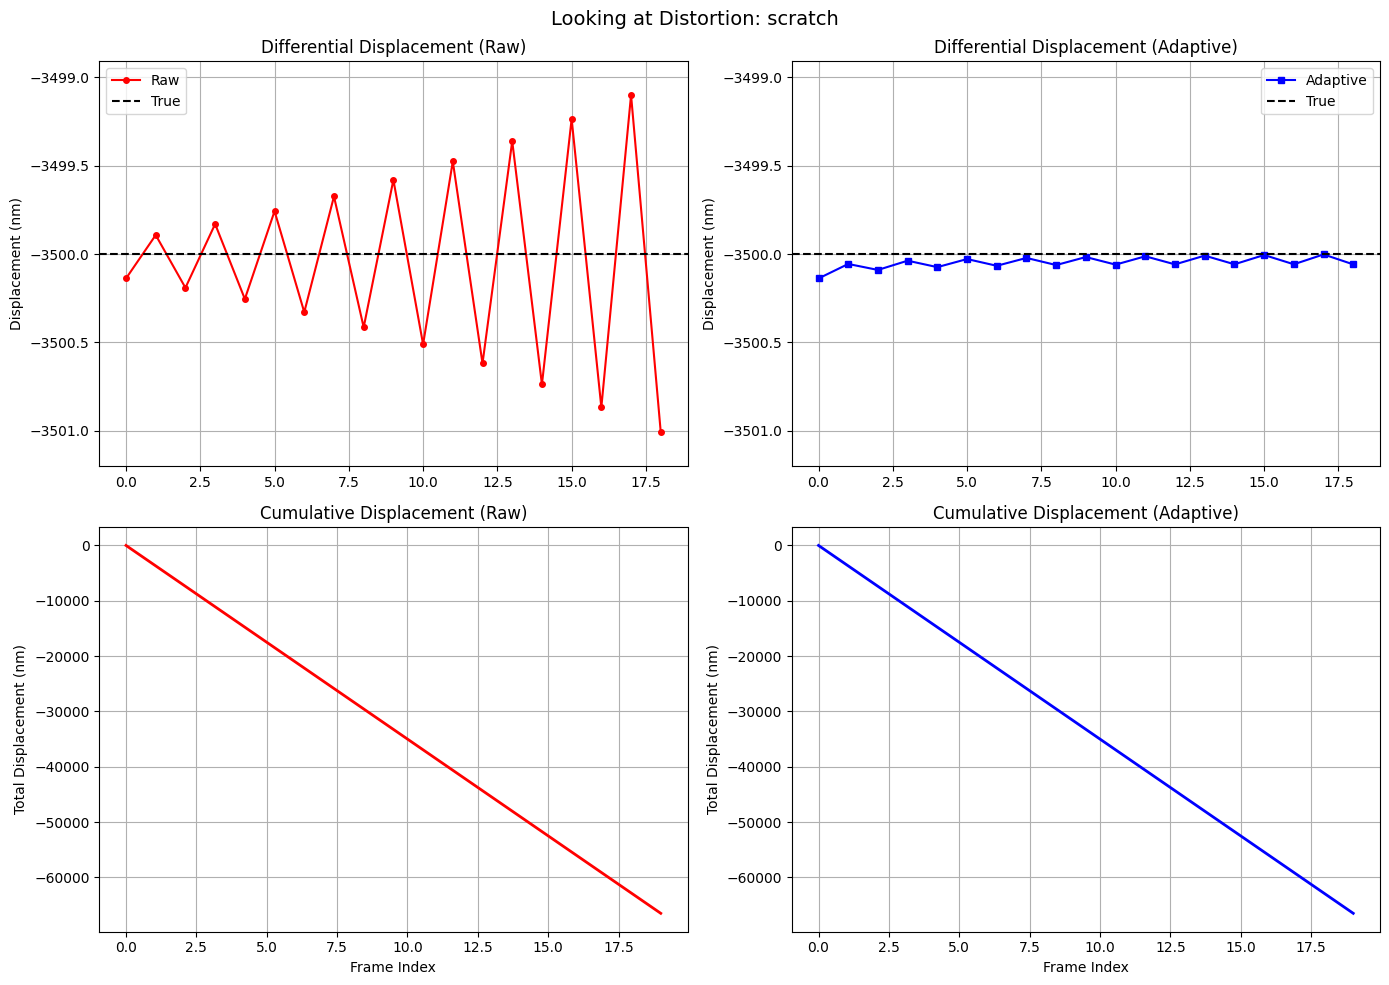

Stats for scratch:
  Distortion Type: scratch
  Raw Accuracy Std (nm): 0.55
  Adaptive KF Std (nm): 0.03
  Improvement (%): 94.03
  Final Raw Disp (nm): -66500.97
  Final Adaptive Disp (nm): -66500.91
  True Final Disp (nm): -66500.00


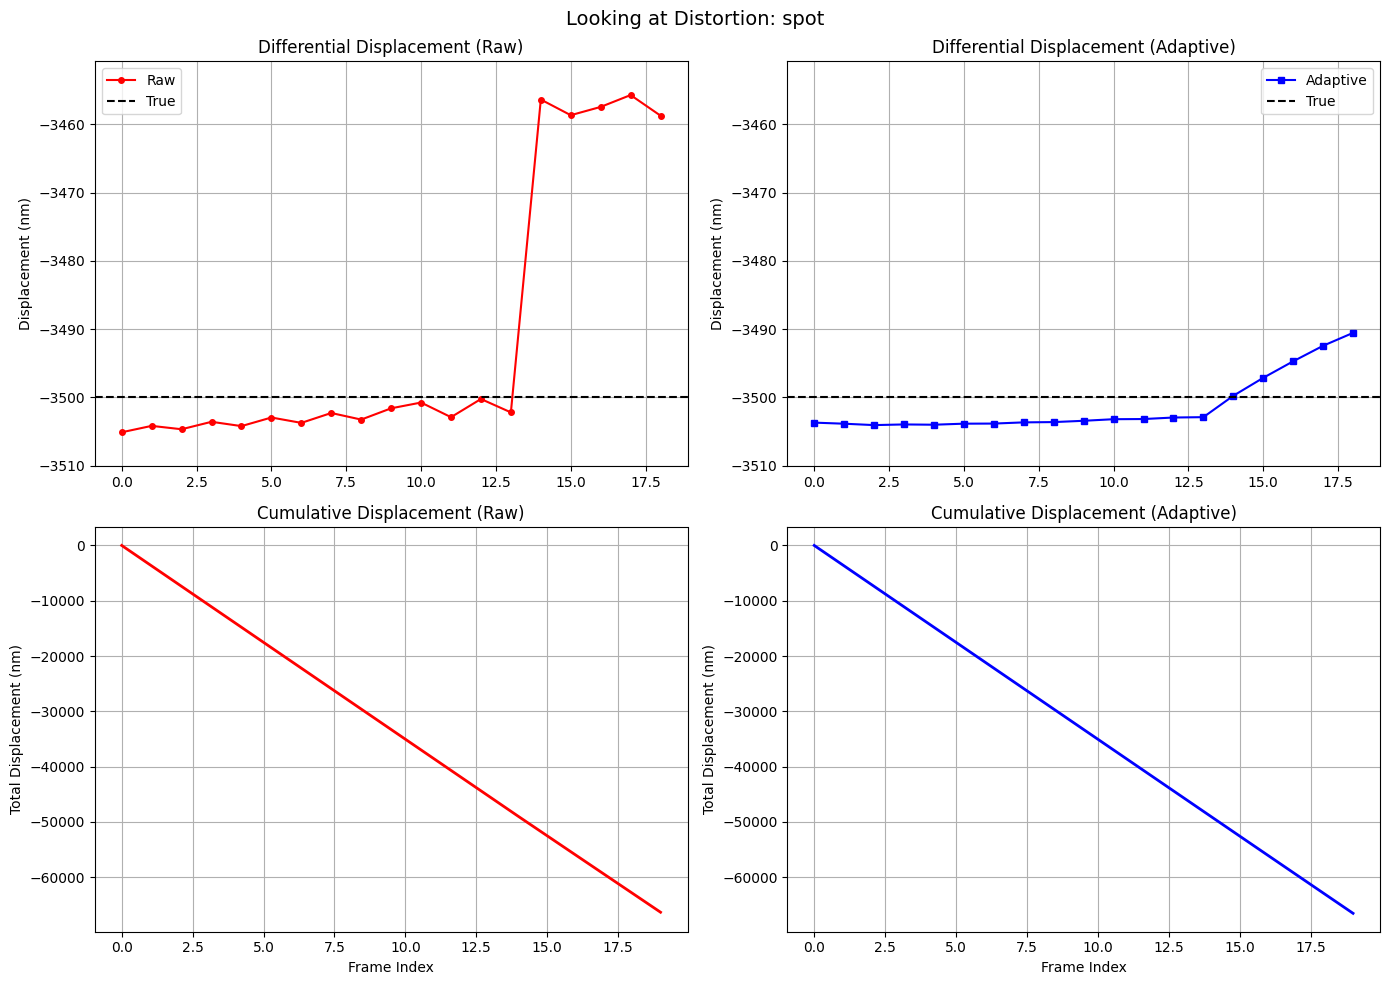

Stats for spot:
  Distortion Type: spot
  Raw Accuracy Std (nm): 20.11
  Adaptive KF Std (nm): 4.18
  Improvement (%): 79.21
  Final Raw Disp (nm): -66328.45
  Final Adaptive Disp (nm): -66524.59
  True Final Disp (nm): -66500.00


In [726]:
def analyze_and_plot(dtype, results):
    raw_diff = results['diff_raw']
    adaptive_diff = results['diff_adaptive']
    raw_cum = results['cumulative_raw']
    adaptive_cum = results['cumulative_adaptive']

    num_steps = len(raw_diff) 
    true_diff_nm = -0.5 * PIXEL_SIZE_UM * 1000  # -3500 nm
    true_final_disp = true_diff_nm * num_steps

    raw_std = np.std(raw_diff - true_diff_nm)
    adaptive_std = np.std(adaptive_diff - true_diff_nm)
    improvement = (1 - adaptive_std / raw_std) * 100 if raw_std > 0 else 0

    all_diff = np.concatenate([raw_diff, adaptive_diff])
    margin = 0.1 * (np.max(all_diff) - np.min(all_diff))  
    ylim_diff = (np.min(all_diff) - margin, np.max(all_diff) + margin)

    all_cum = np.concatenate([raw_cum, adaptive_cum])
    margin_cum = 0.05 * (np.max(all_cum) - np.min(all_cum))  
    ylim_cum = (np.min(all_cum) - margin_cum, np.max(all_cum) + margin_cum)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Looking at Distortion: {dtype}', fontsize=14)
    
    # Absolute Displacement: before and after
    axes[0,0].plot(raw_diff, 'r-o', label='Raw', markersize=4)
    axes[0,0].axhline(true_diff_nm, color='k', linestyle='--', label='True')
    axes[0,0].set_title('Differential Displacement (Raw)')
    axes[0,0].set_ylabel('Displacement (nm)')
    axes[0,0].set_ylim(ylim_diff)
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    axes[0,1].plot(adaptive_diff, 'b-s', label='Adaptive', markersize=4)
    axes[0,1].axhline(true_diff_nm, color='k', linestyle='--', label='True')
    axes[0,1].set_title('Differential Displacement (Adaptive)')
    axes[0,1].set_ylabel('Displacement (nm)')
    axes[0,1].set_ylim(ylim_diff)
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Accumulated displacement: before and after
    axes[1,0].plot(raw_cum, 'r-', linewidth=2, label='Raw')
    axes[1,0].set_title('Cumulative Displacement (Raw)')
    axes[1,0].set_xlabel('Frame Index')
    axes[1,0].set_ylabel('Total Displacement (nm)')
    axes[1,0].set_ylim(ylim_cum)
    axes[1,0].grid(True)
    
    axes[1,1].plot(adaptive_cum, 'b-', linewidth=2, label='Adaptive')
    axes[1,1].set_title('Cumulative Displacement (Adaptive)')
    axes[1,1].set_xlabel('Frame Index')
    axes[1,1].set_ylabel('Total Displacement (nm)')
    axes[1,1].set_ylim(ylim_cum)
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    stats = {
        'Distortion Type': dtype,
        'Raw Accuracy Std (nm)': raw_std,
        'Adaptive KF Std (nm)': adaptive_std,
        'Improvement (%)': improvement,
        'Final Raw Disp (nm)': raw_cum[-1],
        'Final Adaptive Disp (nm)': adaptive_cum[-1],
        'True Final Disp (nm)': true_final_disp
    }
    
    print(f"Stats for {dtype}:")
    for k, v in stats.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.2f}")
        else:
            print(f"  {k}: {v}")
    
    return stats

summary_list = []
for dtype in distortion_types:
    stats = analyze_and_plot(dtype, results_all[dtype])
    summary_list.append(stats)

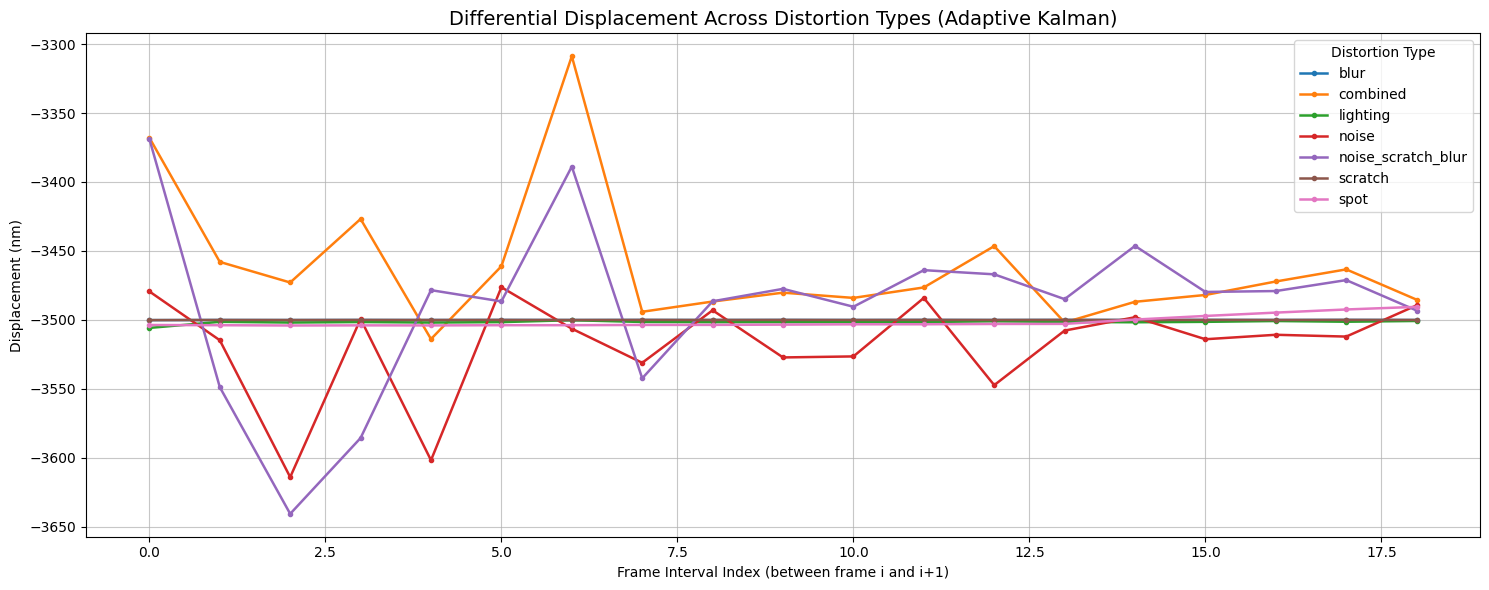

In [727]:
# Compare differential displacements across all distortion types
plt.figure(figsize=(15, 6))

frame_indices = None

for dtype in distortion_types:
    if dtype not in results_all:
        continue
    data = results_all[dtype]
    diff_shifts = data.get('diff_adaptive')
    if diff_shifts is None:
        print(f"Warning: 'diff_adaptive' not found for {dtype}")
        continue
    
    if frame_indices is None:
        frame_indices = np.arange(len(diff_shifts))  
    
    plt.plot(frame_indices, diff_shifts, label=dtype, linewidth=1.8, marker='o', markersize=3)

plt.title('Differential Displacement Across Distortion Types (Adaptive Kalman)', fontsize=14)
plt.xlabel('Frame Interval Index (between frame i and i+1)')
plt.ylabel('Displacement (nm)')
plt.grid(True, alpha=0.7)
plt.legend(title="Distortion Type")
plt.tight_layout()
plt.show()

Примечание:

Медиана хорошо борется с грубыми выбросами (например, spot). Но если искажение более размытое или комбинированное (например, combined, noise_scratch_blur), то оно влияет на соседние окна, и медиана не может его эффективно отфильтровать.